# Identify dual positive neuron gene signature 

**Pinned Environment:** [`envs/sc-scvi.yaml`](../../envs/sc-scvi.yaml)  

In [1]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [2]:
plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams["figure.dpi"] = 300

In [3]:
# make text editable as words in output plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

# Output directories
output_dir = BASE_DIR / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

plot_out_dir = output_dir / "plots"
plot_out_dir.mkdir(parents=True, exist_ok=True)

# Data input paths
# neurons with final labels
input_file = BASE_DIR / "data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad"

# Reporter status table
reporters_path = BASE_DIR / "data/h5ad/export_03/03b_thresholds/reporter_classes_gaussian_thresholds.csv"

In [5]:
# neurons
adata = sc.read_h5ad(input_file)

# updated reporter identification
reporter_classes_updated_dual_neurons = pd.read_csv(reporters_path, index_col=0)

In [6]:
# update reporter ids based on KA thresholding updates
cols_update = ['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']
for col in cols_update:
    if col in adata.obs.columns:
        print(f"deleting {col}")
        del adata.obs[col]

adata.obs = adata.obs.join(reporter_classes_updated_dual_neurons[['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi']])

# add reporter status, either single positive or double postivie
adata.obs['reporter_status'] = 'none'
adata.obs.loc[adata.obs['EGFP_Seq1_hi']==True, 'reporter_status'] = 'EGFP_Seq1_hi'
adata.obs.loc[adata.obs['dTomato_Seq2_hi']==True, 'reporter_status'] = 'dTomato_Seq2_hi'
adata.obs.loc[adata.obs['EGFP_dTomato_dual_hi']==True, 'reporter_status'] = 'EGFP_dTomato_dual_hi'

deleting EGFP_Seq1_hi
deleting dTomato_Seq2_hi
deleting EGFP_dTomato_dual_hi
deleting reporter_status


In [7]:
# Show single+ all together
counts_series = adata.obs.value_counts(['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi'])
counts_df = counts_series.reset_index(name='cell_count')
counts_df

,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,cell_count
0,False,False,False,22120
1,True,False,False,139
2,False,True,False,133
3,True,True,True,19


### Plot

In [8]:
plt.rcdefaults()
plt.rcParams["figure.dpi"] = 150

## Plotting functions

In [9]:
def kde_grid_plot(
    adata,
    genes,
    group_col="EGFP_dTomato_dual_hi",   # group column to compare True vs False
    ncols=5,                             # number of columns in grid
    figsize=(12, 6),
    gene_fontsize=14                     # NEW: control gene title size
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    import math

    sns.set_theme(style="ticks")

    # --- Robust conversion of group_col to boolean ---
    raw_group = adata.obs[group_col]

    if isinstance(raw_group.dtype, pd.CategoricalDtype):
        group_bool = raw_group.astype(str) == "True"
    elif raw_group.dtype == bool:
        group_bool = raw_group.values
    else:
        group_bool = raw_group.astype(str).str.lower().isin(["true", "1", "yes"]).values

    # Extract expression values for each gene
    df = adata.to_df()[genes]

    n = len(genes)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=False,
        sharey=False
    )

    axes = axes.flatten()

    for i, gene in enumerate(genes):
        ax = axes[i]
        x = df[gene].values

        # KDE for False (black)
        sns.kdeplot(
            x[~group_bool],
            ax=ax,
            fill=True,
            color="black",
            alpha=0.25,
            linewidth=3,
            label="False"
        )

        # KDE for True (blue)
        sns.kdeplot(
            x[group_bool],
            ax=ax,
            fill=True,
            color="blue",
            alpha=0.5,
            linewidth=2,
            label="True"
        )

        # --- Italicized, configurable gene name ---
        ax.set_title(
            f"$\\it{{{gene}}}$",
            fontsize=gene_fontsize
        )

        # ax.set_yticks([])
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelsize=8)

    # Hide unused axes (if any)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    sns.despine()
    plt.tight_layout()

    return fig

## Neuron label Top Marker Genes

In [10]:
adata.obs["neuron_label"] = adata.obs["neuron_label"].astype("category")
adata.obs["neuron_label"] = adata.obs["neuron_label"].cat.remove_unused_categories()

In [11]:
sc.tl.rank_genes_groups(adata, groupby="neuron_label", method="wilcoxon")

In [12]:
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,Abeta-Field,Hapln1,52.491867,3.370802,0.000000e+00,0.000000e+00
1,Abeta-Field,Cntn1,49.403072,1.782196,0.000000e+00,0.000000e+00
2,Abeta-Field,Endod1,46.375473,1.185746,0.000000e+00,0.000000e+00
3,Abeta-Field,Hopx,45.988441,2.061731,0.000000e+00,0.000000e+00
4,Abeta-Field,Gfra1,44.374371,1.716223,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
7595,TrpM8,Scn10a,-27.428131,-2.618770,1.266999e-165,2.865831e-164
7596,TrpM8,F2rl2,-28.468809,-2.226695,2.851323e-178,7.524323e-177
7597,TrpM8,Resp18,-28.797789,-2.631424,2.286224e-182,6.387980e-181
7598,TrpM8,Asic2,-30.763878,-1.723815,7.976066e-208,3.788631e-206


In [13]:
log2fc_threshold = 2
pval_threshold = 0.05
markers_filtered = markers[
    (markers["logfoldchanges"] > log2fc_threshold)
    & (markers["pvals_adj"] < pval_threshold)
].copy()

#### Extract top 5 genes for each group

In [14]:
top_genes = (
    markers_filtered.sort_values(
        by=["group", "logfoldchanges"], ascending=[True, False]
    )  # Sort by group and log2FC
    .groupby("group")["names"]  
    .head(5)  
    .tolist()  
)

/tmp/ipykernel_185/2505543662.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")["names"]


In [15]:
plt.rcParams["font.size"] = 16

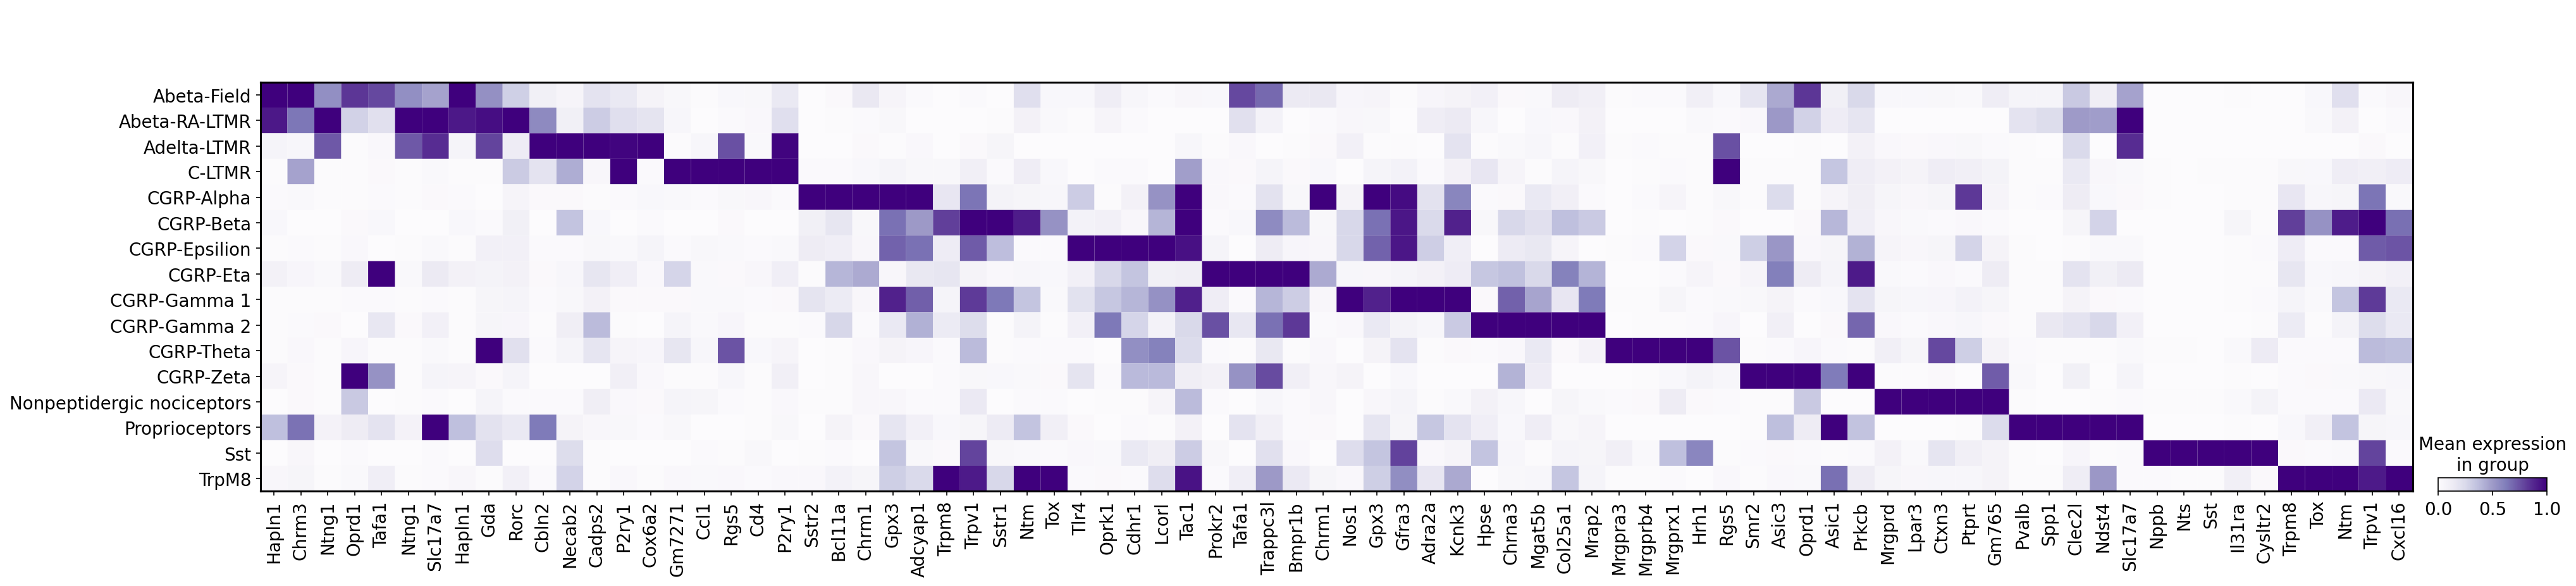

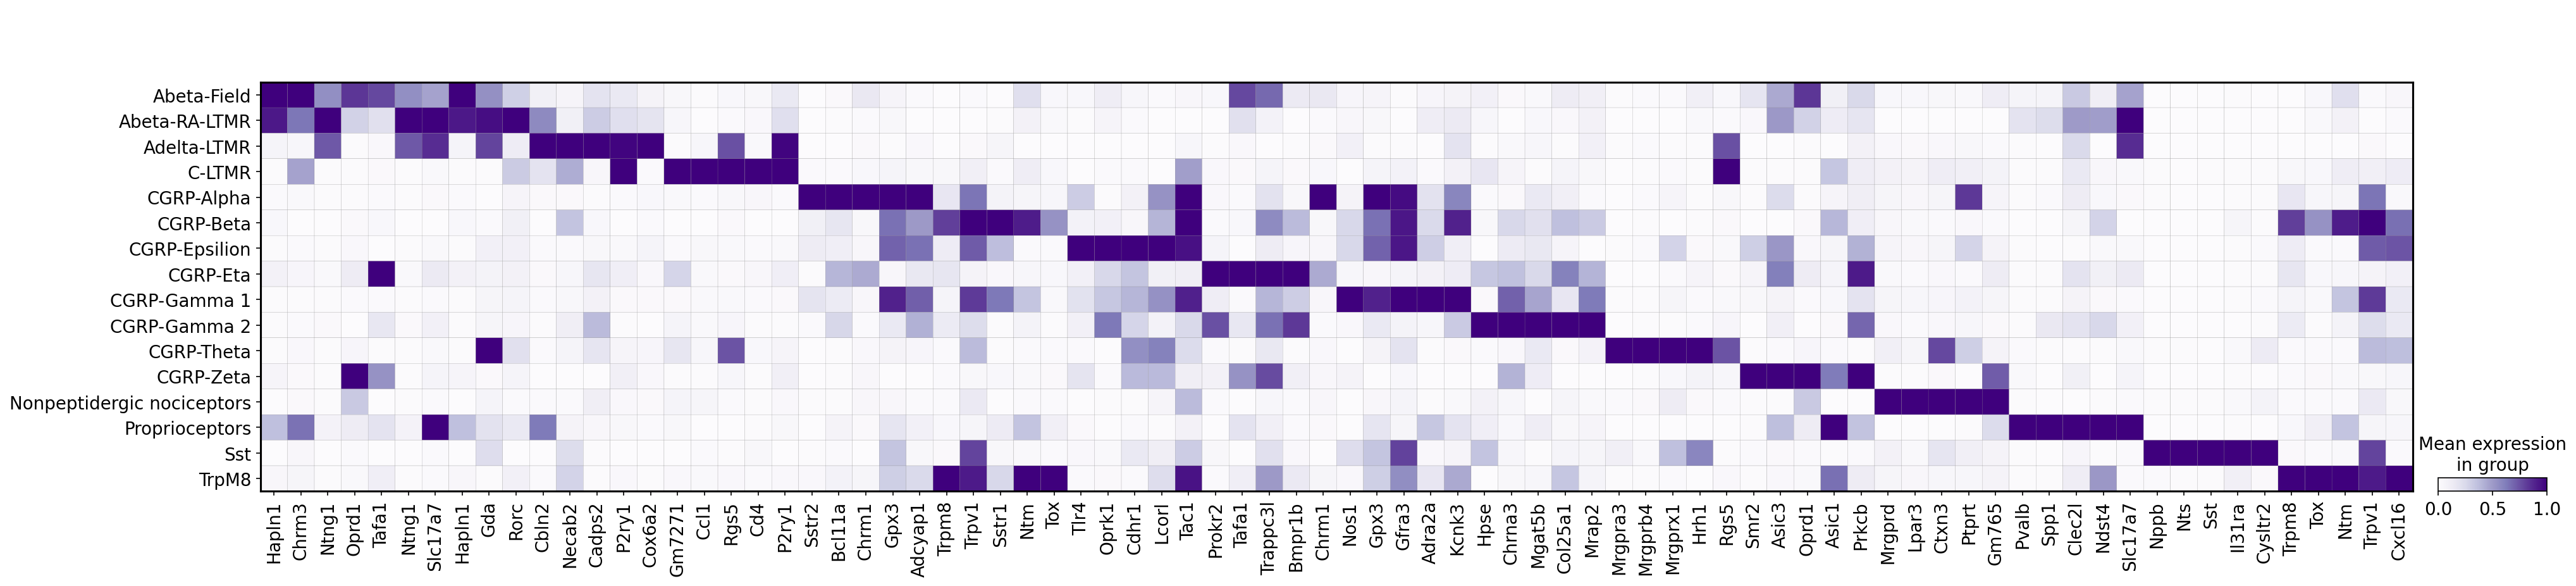

In [16]:
# pdf saving makes the gridlines big, so save both png and pdf, attempting to decrease gridlines
sc.pl.matrixplot(
    adata,
    var_names=top_genes,
    groupby="neuron_label",
    title="",
    standard_scale = 'var',
    cmap = 'Purples',
    edgecolor=None,
    # linewidth= 0.01,
    show=False
)
plt.savefig(os.path.join(plot_out_dir, 'neuron_marker_heatmap.pdf'), bbox_inches='tight', transparent=True)

sc.pl.matrixplot(
    adata,
    var_names=top_genes,
    groupby="neuron_label",
    title="",
    standard_scale = 'var',
    cmap = 'Purples',
    show=False
)
plt.savefig(os.path.join(plot_out_dir, 'neuron_marker_heatmap.png'), bbox_inches='tight', transparent=True)

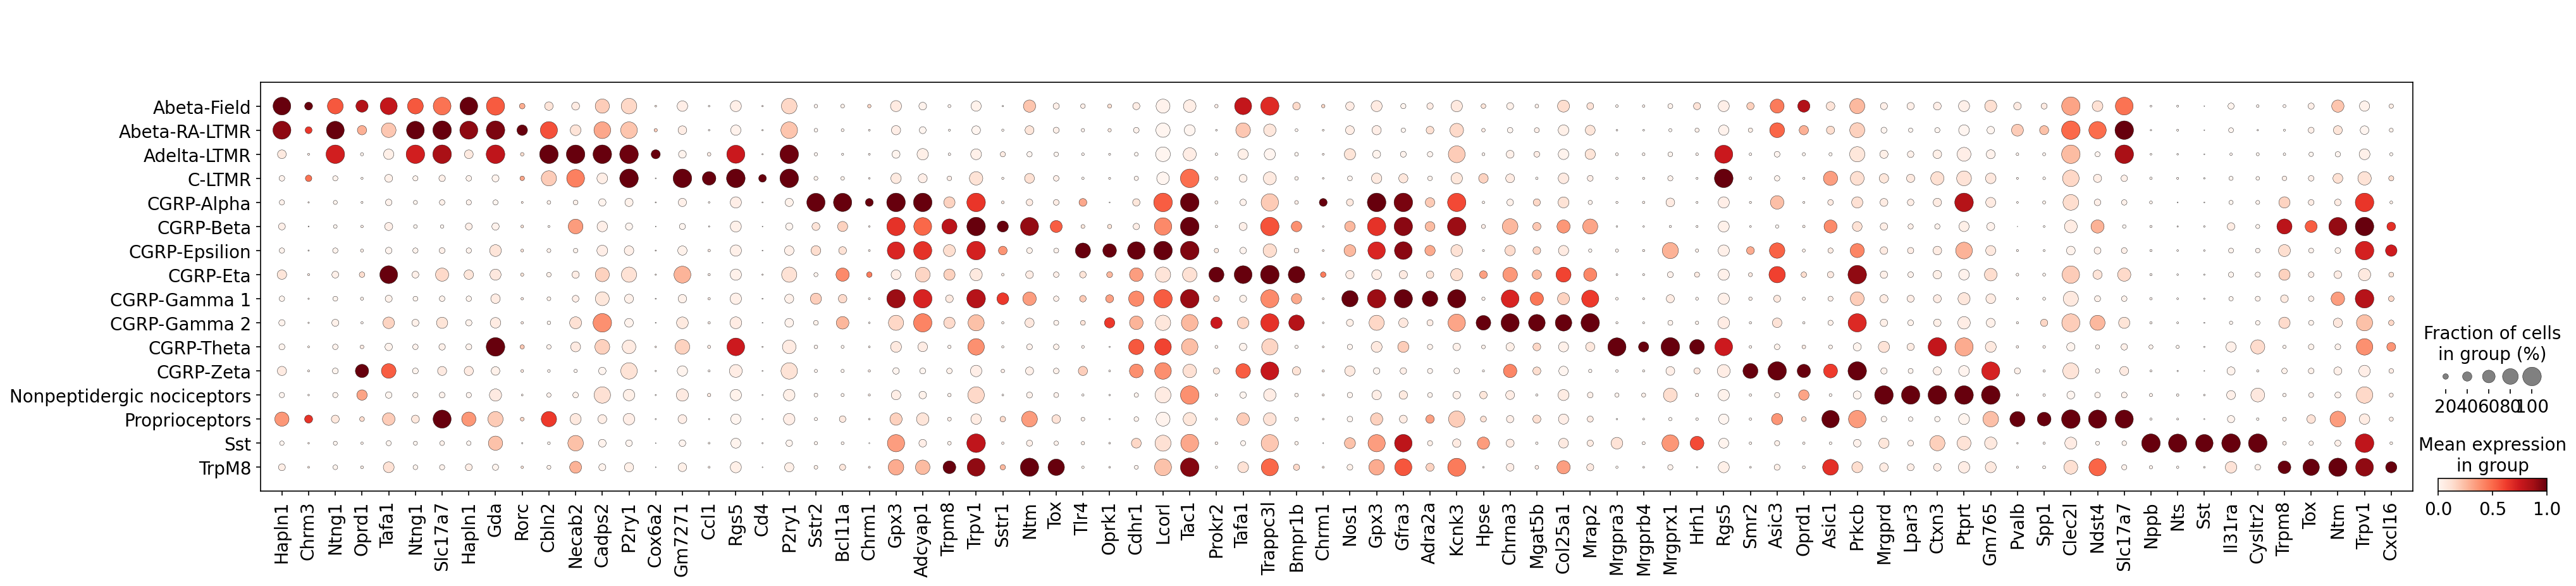

In [17]:
sc.pl.dotplot(
    adata,
    var_names=top_genes,
    groupby="neuron_label",
    title="",
    standard_scale = 'var',
   # save = '_.pdf',
    cmap = 'Reds'
)

In [18]:
markers_filtered.to_csv(f"{output_dir}/marker-genes-filtered.tsv", 
                        sep="\t", index=False)

markers.to_csv(f"{output_dir}/marker-genes-full.tsv", 
                        sep="\t", index=False)

# Dual positive marker genes

In [19]:
adata.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    22392
True        19
Name: count, dtype: int64

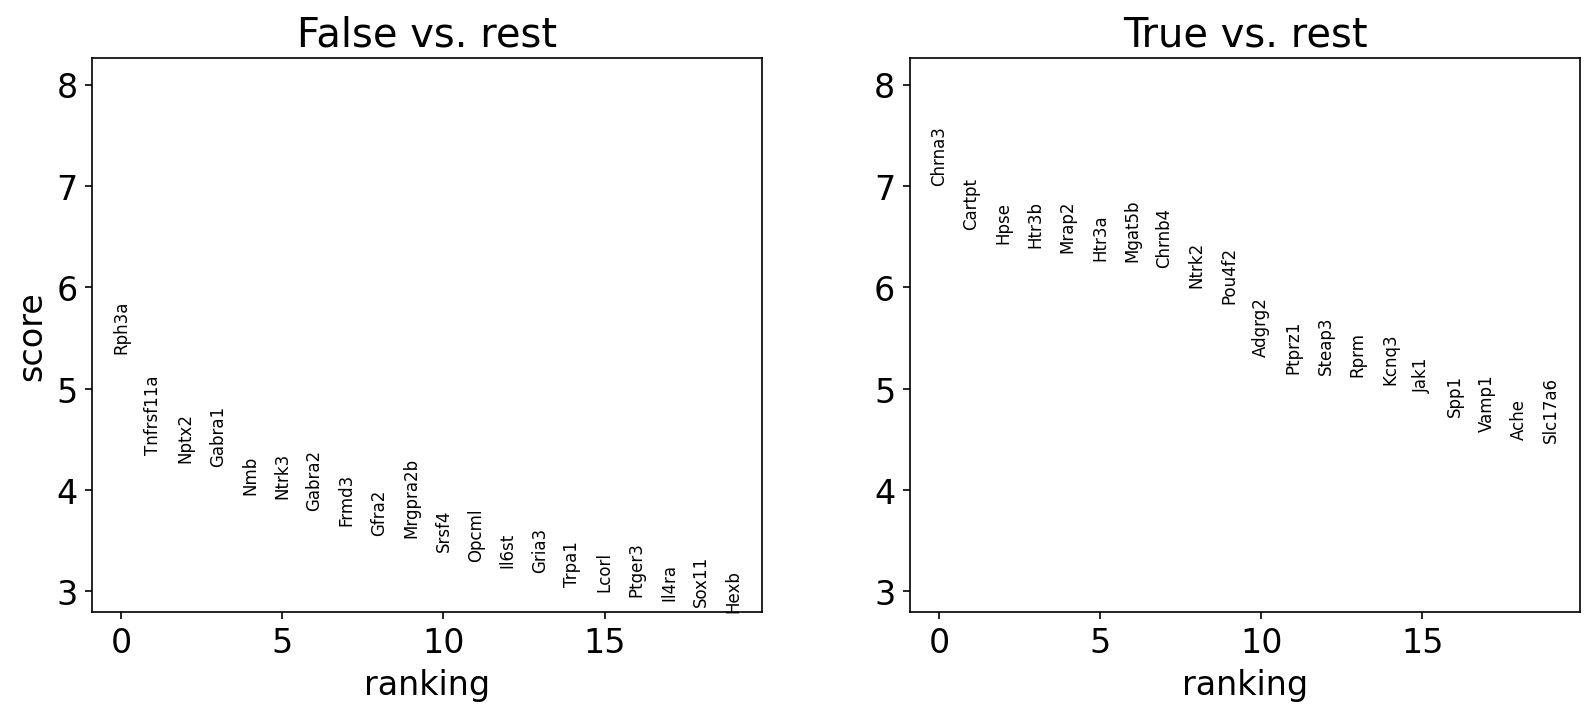

['Chrna3', 'Cartpt', 'Hpse', 'Htr3b', 'Mrap2', 'Htr3a', 'Mgat5b', 'Chrnb4', 'Ntrk2', 'Pou4f2']


In [20]:
adata.obs["EGFP_dTomato_dual_hi"] = adata.obs["EGFP_dTomato_dual_hi"].astype(str)
sc.tl.rank_genes_groups(adata, groupby="EGFP_dTomato_dual_hi", method="wilcoxon")

markers = sc.get.rank_genes_groups_df(adata, group=None)

# plot 
sc.pl.rank_genes_groups(adata, groupby="EGFP_dTomato_dual_hi", method="wilcoxon")

# top dual+ genes
top_genes_dual = (
    markers[markers["group"] == "True"]
    .head(10)["names"]
    .tolist()
)

print(top_genes_dual)

In [21]:
plt.rcParams["font.size"] = 15

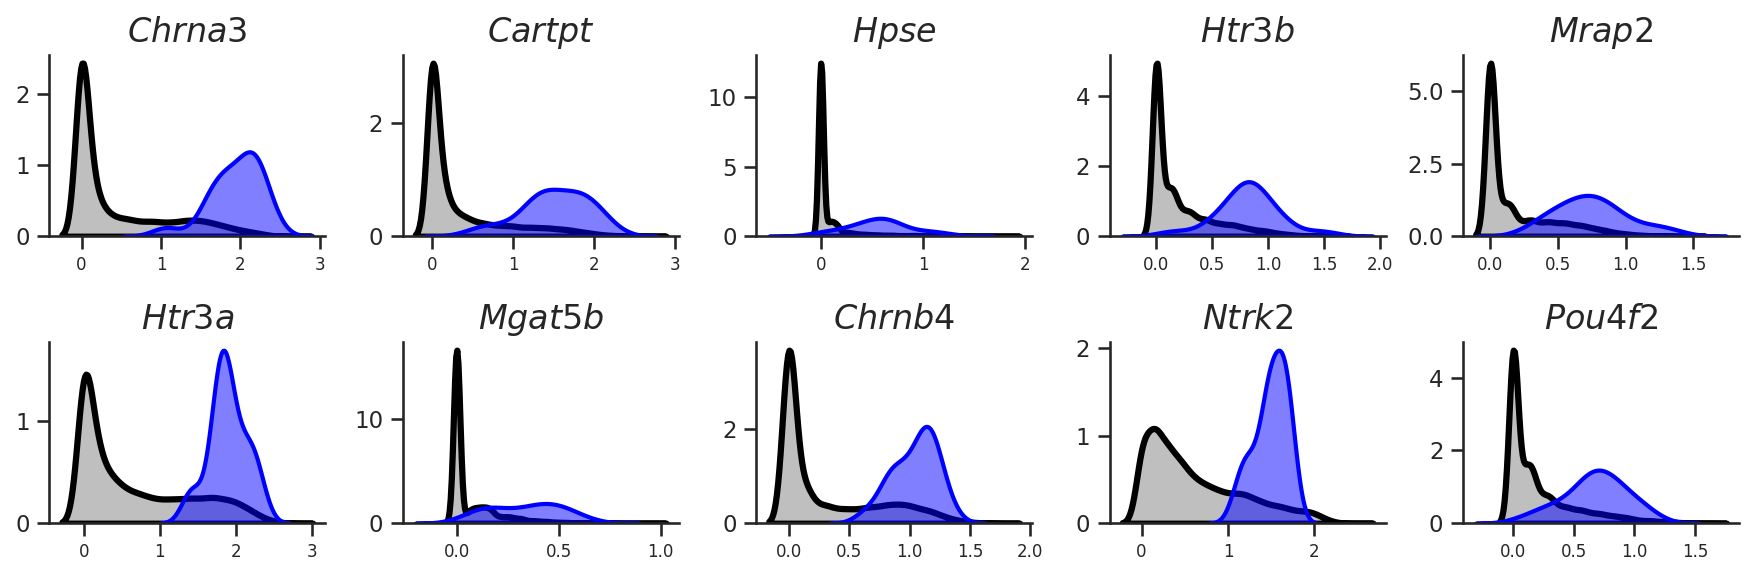

In [23]:
fig = kde_grid_plot(
    adata,
    genes=top_genes_dual,
    group_col="EGFP_dTomato_dual_hi",
    ncols=5,
    figsize=(12, 4),
    gene_fontsize = 16
)
plt.savefig(os.path.join(plot_out_dir, "dual_postive_comparison_allneurons_top10.pdf"), format='pdf', bbox_inches='tight')

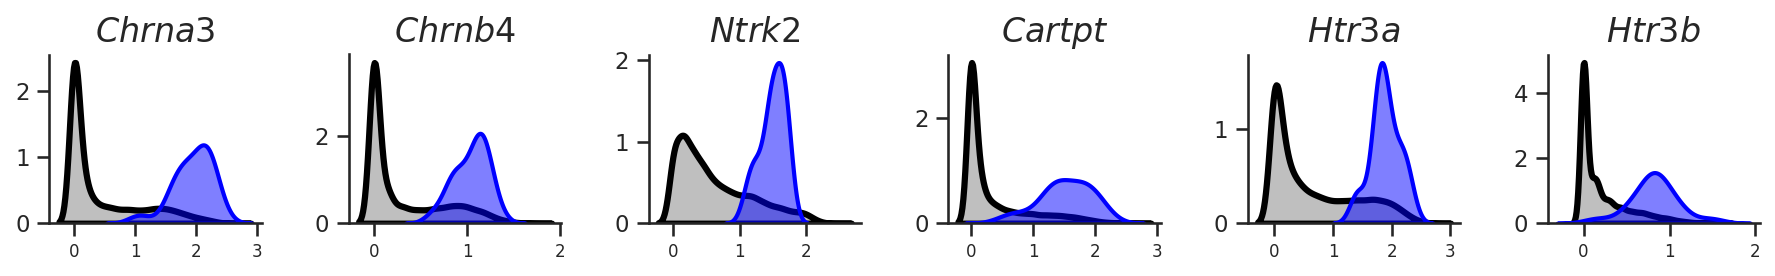

In [22]:

genes = ['Chrna3', 'Chrnb4', 'Ntrk2', 'Cartpt', 'Htr3a', 'Htr3b']
fig = kde_grid_plot(
    adata,
    genes=genes,
    group_col="EGFP_dTomato_dual_hi",
    ncols=6,
    figsize=(12, 2),
    gene_fontsize = 16
)
plt.savefig(os.path.join(plot_out_dir, "dual_postive_comparison_allneurons_top10_select6.pdf"), format='pdf', bbox_inches='tight')

## Dual positive - CGCRP gamma only 
Here we're comparing the dual-positive to other neurons within the CGRP gamma populations only

In [24]:
adata_CGRPg = adata[adata.obs['neuron_label'].isin(['CGRP-Gamma 1', 'CGRP-Gamma 2']), :].copy()
adata_CGRPg.shape

# # below also gives the same
# adata_CGRPg = adata[adata.obs['seurat_labels'] == 'CGRP-Gamma'].copy()
# adata_CGRPg.shape

(6186, 475)

In [25]:
adata_CGRPg.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    6168
True       18
Name: count, dtype: int64

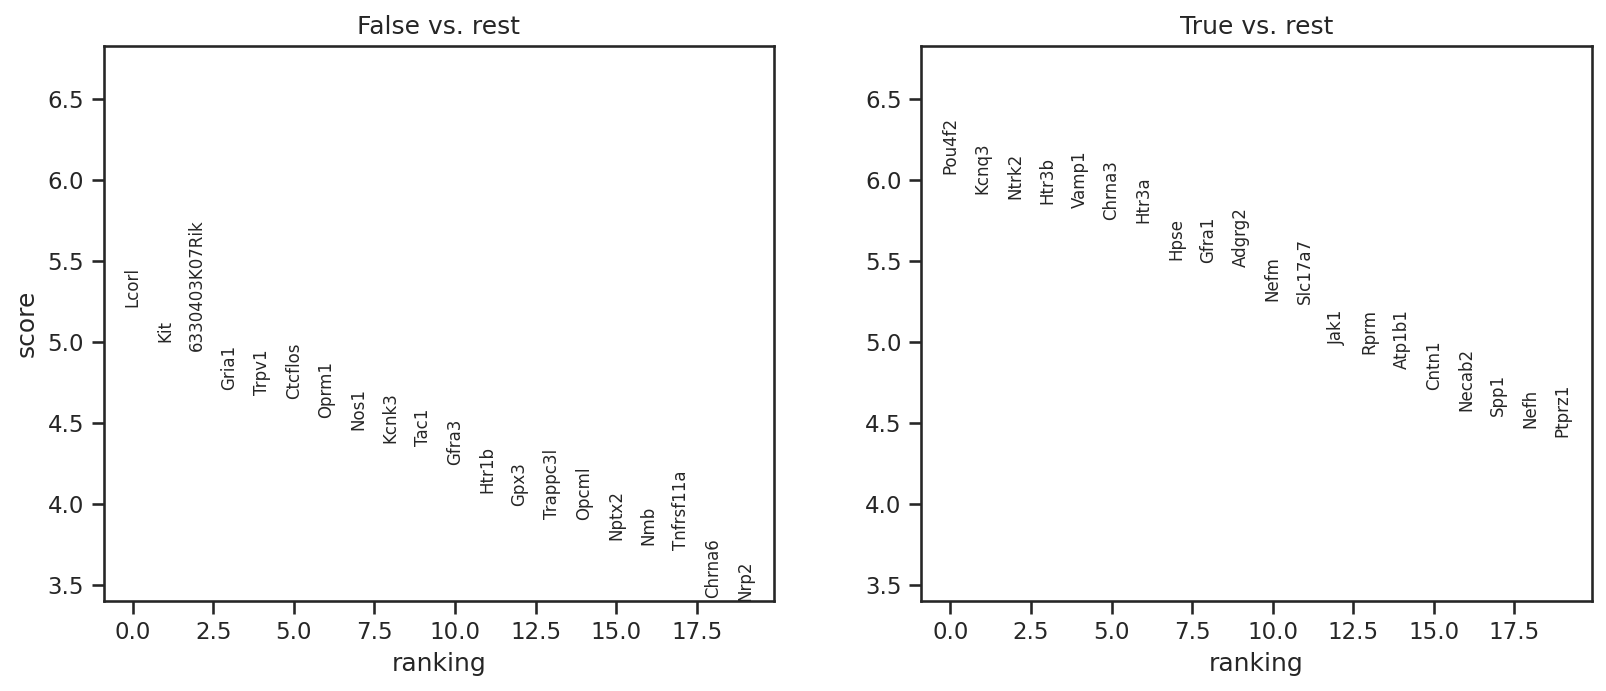

['Pou4f2', 'Kcnq3', 'Ntrk2', 'Htr3b', 'Vamp1', 'Chrna3', 'Htr3a', 'Hpse', 'Gfra1', 'Adgrg2']


In [26]:
adata_CGRPg.obs["EGFP_dTomato_dual_hi"] = adata_CGRPg.obs["EGFP_dTomato_dual_hi"].astype(str)
sc.tl.rank_genes_groups(adata_CGRPg, groupby="EGFP_dTomato_dual_hi", method="wilcoxon")

markers = sc.get.rank_genes_groups_df(adata_CGRPg, group=None)

# plot 
sc.pl.rank_genes_groups(adata_CGRPg, groupby="EGFP_dTomato_dual_hi", method="wilcoxon")

# top dual+ genes
top_genes_dual = (
    markers[markers["group"] == "True"]
    .head(10)["names"]
    .tolist()
)

print(top_genes_dual)

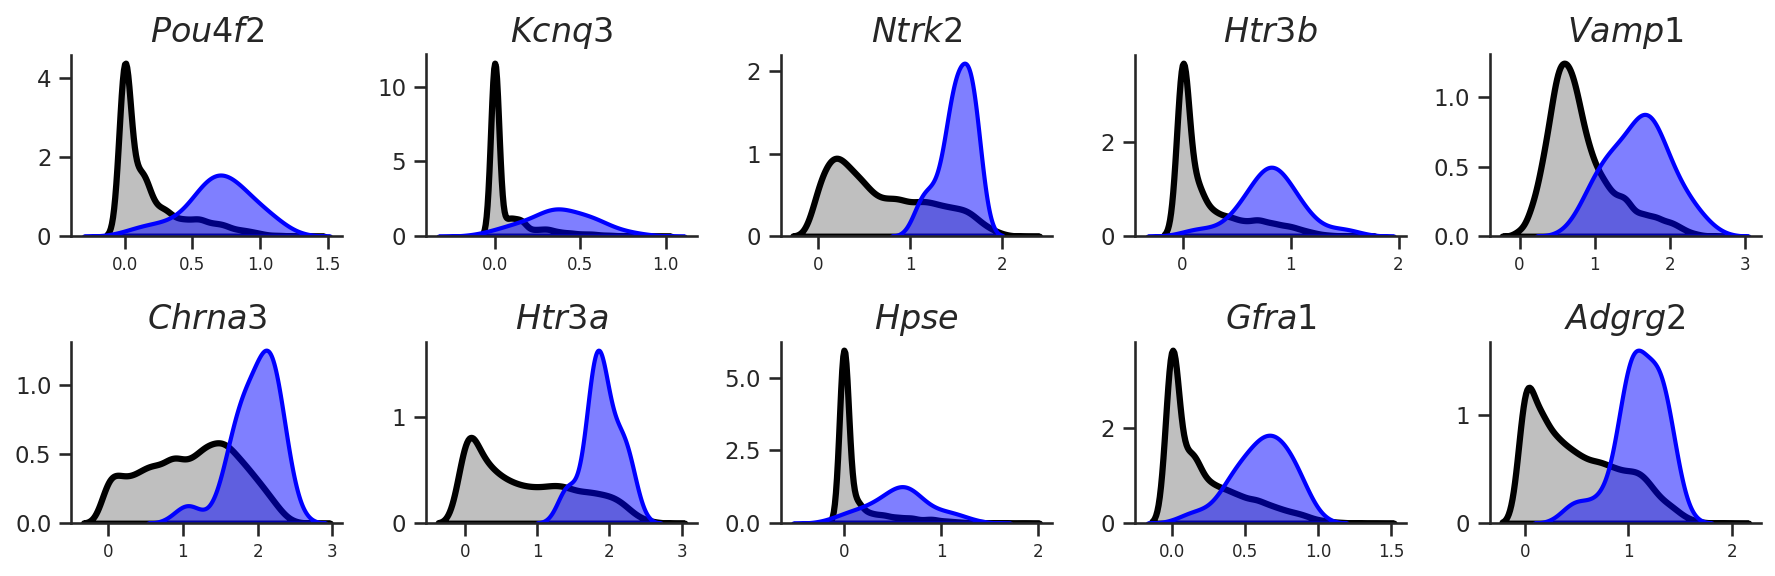

In [27]:
fig = kde_grid_plot(
    adata_CGRPg,
    genes=top_genes_dual,
    group_col="EGFP_dTomato_dual_hi",
    ncols=5,
    figsize=(12, 4),
    gene_fontsize = 16
)
plt.savefig(os.path.join(plot_out_dir, "dual_postive_comparison_CGRPgamma_top10_5cols.pdf"), format='pdf', bbox_inches='tight')

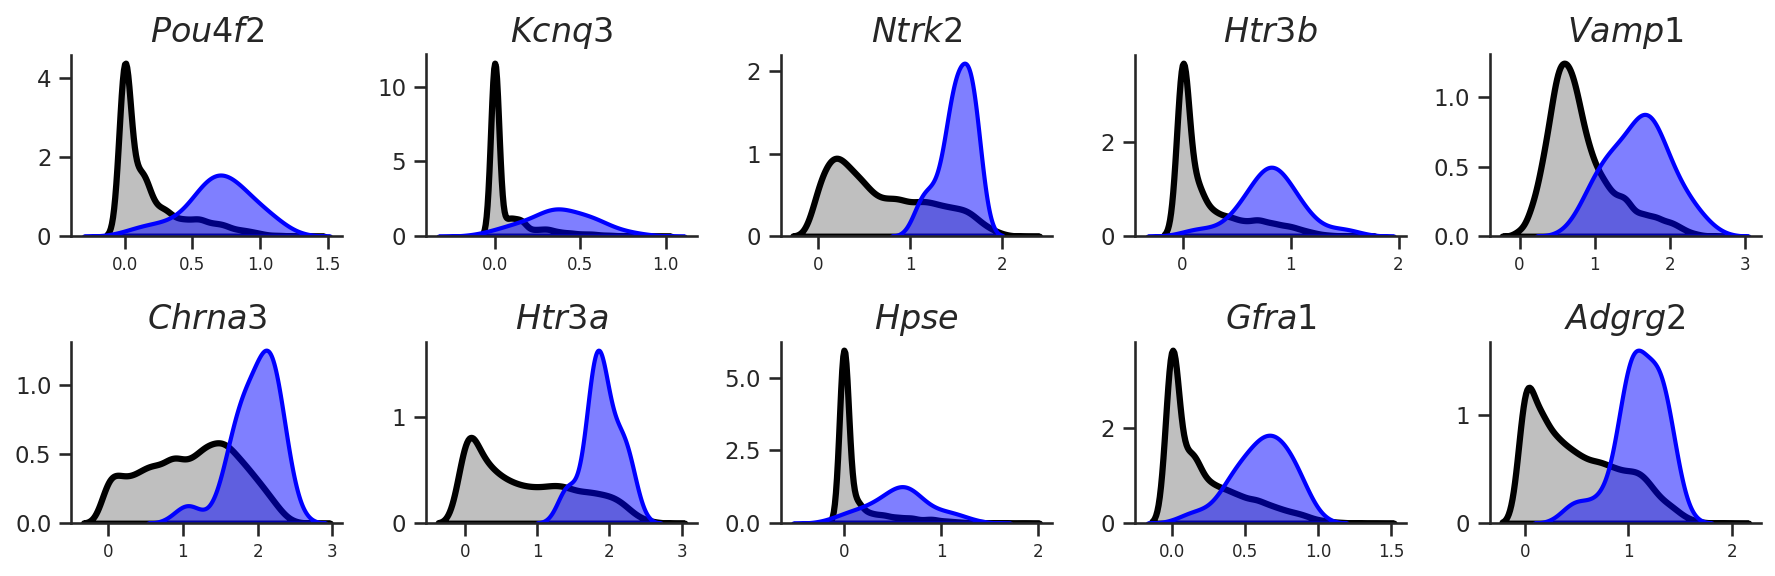

In [28]:
fig = kde_grid_plot(
    adata_CGRPg,
    genes=top_genes_dual,
    group_col="EGFP_dTomato_dual_hi",
    ncols=5,
    figsize=(12, 4),
    gene_fontsize = 16
)
plt.savefig(os.path.join(plot_out_dir, "dual_postive_comparison_CGRPgamma_top10_5cols.pdf"), format='pdf', bbox_inches='tight')